**1. 讀取各個需求與答案**

In [1]:
import json

test_gold = []
for i in range(1, 53):
    filename = f"../data/processed/test_gold/{i:03}.json"
    with open(filename, "r", encoding="utf-8") as f:
        test_gold.append(json.load(f))
print(test_gold)

[{'user_book_needs': '使用者的目標是學習商業微積分相關的基礎概念，並且他已具備一些微積分的基礎知識，沒有特定的應用領域', 'books': [{'id': '990052691730107976', 'title': '商用微積分 = Calculus for business'}, {'id': '990051193990107976', 'title': '商用微積分'}, {'id': '990060401900107976', 'title': '商用微積分'}, {'id': '990052968700107976', 'title': '商用微積分 = Brief calculus'}, {'id': '990052361310107976', 'title': '商用微積分 = Brief applied calculus'}, {'id': '990060238820107976', 'title': '現代商用微積分 = Modern commercial calculus'}, {'id': '990052069630107976', 'title': '現代商用微積分'}, {'id': '990060053120107976', 'title': '商用微積分 = Calculus for business'}, {'id': '990052567890107976', 'title': '商用微積分 = Adapted From Calculus'}, {'id': '990052684510107976', 'title': '商用微積分(第九版) = Applied calculus for business, economics, and the social and life science'}]}, {'user_book_needs': '使用者的目標是學習有關電腦病毒的基礎知識，包括歷史、類型和防治方法，並且他們的技術水平為初學者', 'books': [{'id': '990051186810107976', 'title': 'Easy to know電腦病毒'}, {'id': '990050146620107976', 'title': '解毒大師 : SCAN 與 PRO-SCAN 使用圖例入

**2. 根據各個需求生成答案 [Baseline]**

In [2]:
import os
import json
import requests
from dotenv import load_dotenv
load_dotenv()

ES_API_URL = os.getenv("ES_API_URL")
ES_API_KEY = os.getenv("ES_API_KEY")
header = {
    "Authorization": f"Apikey {ES_API_KEY}",
    "Content-Type": "application/json"
}
result_baseline = []
for data in test_gold:
    result = {"user_book_needs": data["user_book_needs"], "books": []}
    post_data = {
        "query": {
            "simple_query_string": {
                "query": result["user_book_needs"]
            }
        }
    }
    response = requests.get(f"{ES_API_URL}/books/_search?size=10", headers=header, json=post_data)
    print(response.json())
    for book in response.json()["hits"]["hits"]:
        result["books"].append({
            "id": book["_source"]["id"],
            "title": book["_source"]["title"]
        })
    result_baseline.append(result)
print(json.dumps(result_baseline, indent=2, ensure_ascii=False))

{'took': 9, 'timed_out': False, '_shards': {'total': 1, 'successful': 1, 'skipped': 0, 'failed': 0}, 'hits': {'total': {'value': 9472, 'relation': 'eq'}, 'max_score': 40.99634, 'hits': [{'_index': 'books', '_id': '990051908290107976', '_score': 40.99634, '_source': {'id': '990051908290107976', 'title': '基礎微積分'}}, {'_index': 'books', '_id': '990051291210107976', '_score': 39.104176, '_source': {'id': '990051291210107976', 'title': '基礎微積分精要'}}, {'_index': 'books', '_id': '990052488760107976', '_score': 37.378967, '_source': {'id': '990052488760107976', 'title': '隨機微積分基礎'}}, {'_index': 'books', '_id': '990050805720107976', '_score': 35.799553, '_source': {'id': '990050805720107976', 'title': '分析基礎課程 : 微積分'}}, {'_index': 'books', '_id': '990052355250107976', '_score': 35.749958, '_source': {'id': '990052355250107976', 'title': '基礎分析學之一 : 單元微積分學'}}, {'_index': 'books', '_id': '990052355210107976', '_score': 33.75782, '_source': {'id': '990052355210107976', 'title': '基礎分析學之二 : 多元微積分學'}}, {'_

**3. 根據各個需求生成答案 [Smart Book Seeker]**

In [3]:
from smart_book_seeker import ConversationManager

result_sbs = []
for data in test_gold:
    result = {"user_book_needs": data["user_book_needs"], "books": []}
    cm = ConversationManager(strategy="iterative_top_k")
    for response in cm.discuss(book_search_needs=result["user_book_needs"]):
        print(f"\033[96m✦\033[0m {response}")
    for book in cm.user_agent.environment.current_books:
        result["books"].append({
            "id": book.id,
            "title": book.title
        })
    result_sbs.append(result)
print(json.dumps(result_sbs, indent=2, ensure_ascii=False))

2025-07-18 11:01:11,433 [INFO] smart_book_seeker.agents.user_needs.handler: User Needs Agent 初始化完成
2025-07-18 11:01:11,440 [INFO] smart_book_seeker.agents.librarian.handler: Librarian Agent 初始化完成
2025-07-18 11:01:12,609 [INFO] httpx: HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-07-18 11:01:12,621 [INFO] smart_book_seeker.agents.user.handler: User Agent 初始化完成
2025-07-18 11:01:12,627 [INFO] smart_book_seeker.agents.librarian.handler: Librarian Agent 初始化完成
2025-07-18 11:01:14,138 [INFO] httpx: HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-07-18 11:01:14,141 [INFO] smart_book_seeker.agents.user.handler: User Agent 初始化完成
2025-07-18 11:01:15,673 [INFO] httpx: HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-07-18 11:01:15,675 [INFO] smart_book_seeker.agents.librarian.tools.handler: [prepare_environment_snapshot]
{
  "initial_book_search_needs": "使用者的目標是學習商業微積分相關的基礎概念，並且他已具備一些微積分的基礎知識，沒有特定的應用領域",
  "

✦ [Librarian Agent] 我根據您的需求，搜尋到以下書籍：
[{"id": "990051908290107976", "title": "基礎微積分", "searched_at_turn": 1}, {"id": "990051291210107976", "title": "基礎微積分精要", "searched_at_turn": 1}, {"id": "990052488760107976", "title": "隨機微積分基礎", "searched_at_turn": 1}, {"id": "990050805720107976", "title": "分析基礎課程 : 微積分", "searched_at_turn": 1}, {"id": "990050296070107976", "title": "商學院微積分", "searched_at_turn": 1}, {"id": "990052355210107976", "title": "基礎分析學之二 : 多元微積分學", "searched_at_turn": 1}, {"id": "990050825100107976", "title": "商專微積分總複習", "searched_at_turn": 1}, {"id": "990052355250107976", "title": "基礎分析學之一 : 單元微積分學", "searched_at_turn": 1}, {"id": "990058806790107976", "title": "微積分 /", "searched_at_turn": 1}, {"id": "990051832490107976", "title": "微積分", "searched_at_turn": 1}]


2025-07-18 11:01:28,373 [INFO] httpx: HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-07-18 11:01:28,569 [INFO] smart_book_seeker.agents.user.tools.handler: [generate_rationale_for_book_selection]
{
  "rationale": "1. 《基礎微積分》與《基礎微積分精要》標題明確指出是基礎微積分教材，適合已有微積分基礎的使用者進一步學習，符合需求。\n2. 《商學院微積分》和《商專微積分總複習》明確標示與商業相關，且涵蓋微積分，直接符合使用者想學習商業微積分的需求。\n3. 《分析基礎課程 : 微積分》與《基礎分析學之一 : 單元微積分學》和《基礎分析學之二 : 多元微積分學》屬於較深入的微積分分析課程，適合有基礎者，但可能偏理論，仍有參考價值。\n4. 《微積分 /》與《微積分》標題較廣泛，可能涵蓋基礎到進階內容，適合補充學習。\n5. 《隨機微積分基礎》偏向隨機過程與微積分結合，較專業且不完全符合基礎商業微積分需求，故不優先。\n綜合考量，優先選擇標題中含有「商業」或「基礎微積分」且適合已有基礎的書籍，次選較全面的微積分教材。"
}
2025-07-18 11:01:38,257 [INFO] httpx: HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-07-18 11:01:38,510 [INFO] smart_book_seeker.agents.user.tools.handler: [select_books]
{
  "accepted_books": [
    {
      "id": "990051908290107976",
      "title": "基礎微積分",
      "searched_at_turn": 1,
      "reason_for_acceptance": "標題明確為基礎微積分，適合已有微積分基礎的使用者，符合需求。"
    },
    {

✦ [User Agent] 我已根據我的需求，對你提供的書籍進行篩選，篩選結果如下：
{"selection_at_turn": 1, "candidate_books": [{"book": {"id": "990051908290107976", "title": "基礎微積分", "searched_at_turn": 1}, "selection_result": "accepted", "selection_reason": "標題明確為基礎微積分，適合已有微積分基礎的使用者，符合需求。"}, {"book": {"id": "990051291210107976", "title": "基礎微積分精要", "searched_at_turn": 1}, "selection_result": "accepted", "selection_reason": "標題明確為基礎微積分教材，適合進一步學習基礎微積分。"}, {"book": {"id": "990050296070107976", "title": "商學院微積分", "searched_at_turn": 1}, "selection_result": "accepted", "selection_reason": "明確標示與商業相關，直接符合學習商業微積分的需求。"}, {"book": {"id": "990050825100107976", "title": "商專微積分總複習", "searched_at_turn": 1}, "selection_result": "accepted", "selection_reason": "標示與商業相關，適合複習商業微積分內容。"}, {"book": {"id": "990050805720107976", "title": "分析基礎課程 : 微積分", "searched_at_turn": 1}, "selection_result": "accepted", "selection_reason": "深入的微積分分析課程，適合有基礎者參考。"}, {"book": {"id": "990052355250107976", "title": "基礎分析學之一 : 單元微積分學", "searched_at_turn": 1}, "

2025-07-18 11:01:41,986 [INFO] httpx: HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-07-18 11:01:42,299 [INFO] smart_book_seeker.agents.librarian.tools.handler: [infer_book_search_needs]
{
  "book_search_needs": "使用者已接受多本涵蓋基礎微積分及商業微積分相關書籍，尚需補充更多商業微積分應用案例或實務導向的書籍，以加強實際應用能力。"
}
2025-07-18 11:01:45,163 [INFO] httpx: HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-07-18 11:01:45,349 [INFO] smart_book_seeker.agents.librarian.tools.handler: [generate_rationale]
{
  "rationale": "使用者已經接受多本基礎微積分及商業微積分相關書籍，表示基礎理論部分已有覆蓋。為了更符合使用者需求，應該搜尋涵蓋商業微積分應用案例或實務導向的書籍，這樣能補充實際應用能力。故下一步應執行search_library_catelog，使用更聚焦於商業微積分應用和實務的查詢語句。"
}
2025-07-18 11:01:46,703 [INFO] httpx: HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-07-18 11:01:46,879 [INFO] smart_book_seeker.agents.librarian.tools.handler: [search_library_catalog] 搜尋「商業微積分 應用 實務 案例」
{
  "found_books": [
    {
      "id": "990050556650107976",
      "title": "應用微積分 /

...

✦ [User Agent] 我已根據我的需求，對你提供的書籍進行篩選，篩選結果如下：
{"selection_at_turn": 4, "candidate_books": [{"book": {"id": "990063522110107976", "title": "Node.js設計模式 /", "searched_at_turn": 1}, "selection_result": "accepted", "selection_reason": "符合Node.js設計相關需求，適合進階設計模式學習。"}, {"book": {"id": "990060700360107976", "title": "深入淺出Node.js /", "searched_at_turn": 1}, "selection_result": "accepted", "selection_reason": "適合初學者入門Node.js，涵蓋基礎與實務。"}, {"book": {"id": "990064720140107976", "title": "用Javascript一統前後端 : 御用語言Node.js出巡Web /", "searched_at_turn": 1}, "selection_result": "accepted", "selection_reason": "高度符合需求，涵蓋前後端整合開發。"}, {"book": {"id": "990072199760107976", "title": "頂級優效Web應用框架開發必備 : Node.js超階技能 /", "searched_at_turn": 1}, "selection_result": "accepted", "selection_reason": "強調Web應用框架開發，符合需求。"}, {"book": {"id": "990071798580107976", "title": "JavaScript再上一層樓 : 用新一代Node.js把後端也搞定 /", "searched_at_turn": 1}, "selection_result": "accepted", "selection_reason": "涵蓋Node.js後端開發，符合需求。"}, {"book": {"id": "

2025-07-18 12:23:39,183 [INFO] httpx: HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-07-18 12:23:39,361 [INFO] smart_book_seeker.agents.librarian.tools.handler: [infer_book_search_needs]
{
  "book_search_needs": "目前已找到10本符合Node.js設計與開發網頁前後端的書籍，已滿足使用者需求。"
}
2025-07-18 12:23:42,823 [INFO] httpx: HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-07-18 12:23:43,043 [INFO] smart_book_seeker.agents.librarian.tools.handler: [generate_rationale]
{
  "rationale": "目前已找到10本符合使用者需求的Node.js設計與開發網頁前後端書籍，涵蓋初學者入門到進階設計模式及實務應用，且排除不相關主題。已完全涵蓋使用者需求，建議詢問使用者是否結束本次會話或有其他搜尋需求。"
}
2025-07-18 12:23:49,317 [INFO] httpx: HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-07-18 12:23:49,516 [INFO] smart_book_seeker.agents.librarian.tools.handler: [ask_end_of_session]
{
  "question": "我已找到10本符合您需求的Node.js設計與開發網頁前後端書籍，這些書籍涵蓋了從初學者入門到進階設計模式及實務應用，且排除了不相關主題。請問您是否要結束本次會話，或者您還有其他的書籍搜尋需求？"
}
2025-07-18 12:23:49,519 [INFO] smart_book_seek

✦ [Librarian Agent] 我已找到10本符合您需求的Node.js設計與開發網頁前後端書籍，這些書籍涵蓋了從初學者入門到進階設計模式及實務應用，且排除了不相關主題。請問您是否要結束本次會話，或者您還有其他的書籍搜尋需求？


2025-07-18 12:23:54,851 [INFO] httpx: HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-07-18 12:23:55,001 [INFO] smart_book_seeker.agents.user.tools.handler: [generate_rationale_for_termination_request_decision]
{
  "rationale": "目前已找到且接受的書籍數量達到10本，且這些書籍均符合使用者尋找Node.js設計及開發網頁前後端的需求，涵蓋從入門到進階的多個面向。圖書館員已經進行了4次搜尋，嘗試了多種搜尋策略，並排除了不相關的書籍。基於此，認為圖書館員已經充分滿足使用者的需求，且提供了完整且符合需求的書籍清單，因此接受終止對話請求是合理的。"
}
2025-07-18 12:23:59,251 [INFO] httpx: HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-07-18 12:23:59,417 [INFO] smart_book_seeker.agents.user.tools.handler: [accept_termination_request]
{
  "reason_for_acceptance": "目前已找到且接受的書籍數量達到10本，這些書籍均符合我尋找Node.js設計及開發網頁前後端的需求，涵蓋從入門到進階的多個面向。圖書館員已進行多次搜尋，嘗試多種搜尋策略，並排除不相關書籍，充分滿足我的需求並提供完整且符合需求的書籍清單。因此，我接受終止對話請求。"
}
2025-07-18 12:23:59,418 [INFO] smart_book_seeker.conversation_manager: [User Agent] 持有書籍清單：
[
  {
    "id": "990063522110107976",
    "title": "Node.js設計模式 /",
    "searched_at_turn": 1
  },
  {
    

✦ [User Agent] 目前已找到且接受的書籍數量達到10本，這些書籍均符合我尋找Node.js設計及開發網頁前後端的需求，涵蓋從入門到進階的多個面向。圖書館員已進行多次搜尋，嘗試多種搜尋策略，並排除不相關書籍，充分滿足我的需求並提供完整且符合需求的書籍清單。因此，我接受終止對話請求。
[
  {
    "user_book_needs": "使用者的目標是學習商業微積分相關的基礎概念，並且他已具備一些微積分的基礎知識，沒有特定的應用領域",
    "books": [
      {
        "id": "990051908290107976",
        "title": "基礎微積分"
      },
      {
        "id": "990051291210107976",
        "title": "基礎微積分精要"
      },
      {
        "id": "990050296070107976",
        "title": "商學院微積分"
      },
      {
        "id": "990050825100107976",
        "title": "商專微積分總複習"
      },
      {
        "id": "990050805720107976",
        "title": "分析基礎課程 : 微積分"
      },
      {
        "id": "990052355250107976",
        "title": "基礎分析學之一 : 單元微積分學"
      },
      {
        "id": "990052355210107976",
        "title": "基礎分析學之二 : 多元微積分學"
      },
      {
        "id": "990050556650107976",
        "title": "應用微積分 /"
      },
      {
        "id": "990052463440107976",
        "title": "實用微積分"
      },
      {
        "i

**4. 計算成績**

In [4]:
score_baseline = []
score_sbs = []
for i, data in enumerate(test_gold):
    data["baseline_books"] = result_baseline[i]["books"]
    data["sbs_books"] = result_sbs[i]["books"]
    score = {"baseline": 0, "sbs": 0}
    for book in data["baseline_books"]:
        for ans_book in data["books"]:
            if book["id"] == ans_book["id"]:
                score["baseline"] += 1
    score["baseline"] *= 10
    for book in data["sbs_books"]:
        for ans_book in data["books"]:
            if book["id"] == ans_book["id"]:
                score["sbs"] += 1
    score["sbs"] *= 10
    score_baseline.append(score["baseline"])
    score_sbs.append(score["sbs"])
    print(f"[{data["user_book_needs"]}] Baseline: {score["baseline"]:.2f}, SBS: {score["sbs"]:.2f}")

[使用者的目標是學習商業微積分相關的基礎概念，並且他已具備一些微積分的基礎知識，沒有特定的應用領域] Baseline: 0.00, SBS: 0.00
[使用者的目標是學習有關電腦病毒的基礎知識，包括歷史、類型和防治方法，並且他們的技術水平為初學者] Baseline: 30.00, SBS: 80.00
[使用者的目標是尋找有關量子物理相關的基礎知識，偏好通俗易懂的介紹] Baseline: 0.00, SBS: 30.00
[使用者的目標是尋找有關電子學的基本知識書籍，專注於基本概念和原理] Baseline: 20.00, SBS: 40.00
[使用者的目標是尋找簡單易懂的書籍，以學習有關不同自然生態或是動物生態的基礎知識] Baseline: 20.00, SBS: 20.00
[使用者的目標是尋找有關使用威力導演11版本以上的工具來做剪輯] Baseline: 40.00, SBS: 40.00
[使用者的目標是尋找有關介紹科學家費曼生平的故事] Baseline: 40.00, SBS: 60.00
[使用者的目標是尋找有關太陽能電池的原理、技術等等知識] Baseline: 60.00, SBS: 50.00
[使用者的目標是尋找有關昆蟲的圖片或是各方面的知識] Baseline: 50.00, SBS: 100.00
[使用者的目標是尋找有關怎麼使用TensorFlow來學習有關深度學習的知識] Baseline: 40.00, SBS: 70.00
[使用者的目標是尋找有關怎麼使用Flash CS3來進行動畫製作] Baseline: 30.00, SBS: 50.00
[使用者的目標是尋找有關怎麼使用Flash CS4來進行網頁設計和動畫製作] Baseline: 40.00, SBS: 90.00
[使用者的目標是尋找有關怎麼使用Flash CS5來進行網頁設計和動畫製作的相關書籍] Baseline: 10.00, SBS: 20.00
[使用者的目標是尋找2020~2024年有關AutoCAD的使用方法或是教材] Baseline: 0.00, SBS: 80.00
[使用者的目標是尋找有關怎麼使用Photoshop CS2來進行照片編輯和處理] Baseline: 20.00, SBS: 0.00
[使用者的目標是尋找有關怎麼使用Ph

**5. 畫圖**

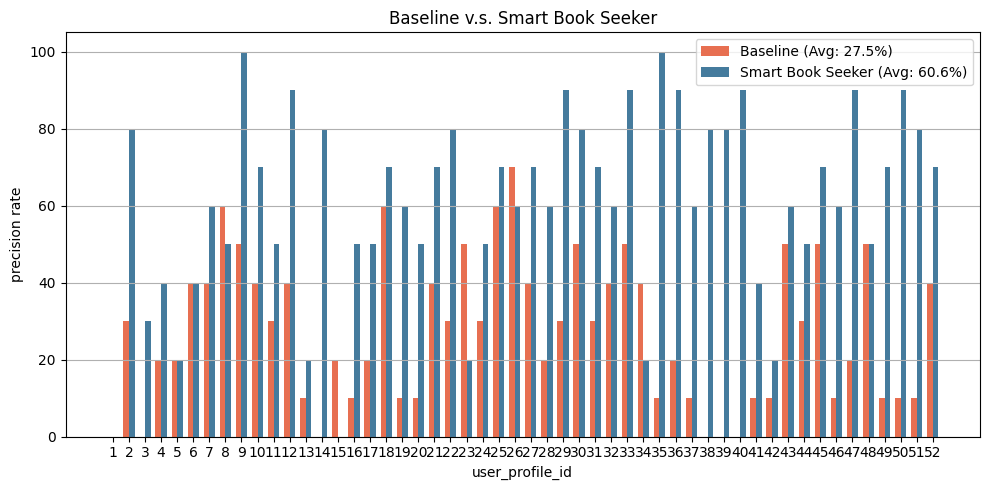

In [5]:
import matplotlib.pyplot as plt

# 資料
base = score_baseline
my =   score_sbs
x = list(range(1, len(base) + 1))

# 計算平均值
base_mean = sum(base) / len(base)
my_mean = sum(my) / len(my)

# 繪圖（改為長條圖）
plt.figure(figsize=(10, 5))
bar_width = 0.35
plt.bar([i - bar_width/2 for i in x], base, width=bar_width, label=f'Baseline (Avg: {base_mean:.1f}%)', color='#E76F51')
plt.bar([i + bar_width/2 for i in x], my, width=bar_width, label=f'Smart Book Seeker (Avg: {my_mean:.1f}%)', color='#457B9D')

plt.xlabel('user_profile_id')
plt.ylabel('precision rate')
plt.title('Baseline v.s. Smart Book Seeker')

plt.legend(loc='upper right')
plt.grid(axis='y')
plt.tight_layout()
plt.xticks(x)

plt.show()